# Handwritten Muse2 digits

Use the same preprocessing and model from Muse_[12].ipynb to and do a binary classification on digit vs. blank to see if it can perform just as well on this dataset.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os

folder_path = '/content/drive/My Drive/ML project'

# Check if the path exists
if os.path.exists(folder_path):
    print("Folder found.")
else:
    print("Folder not found.")

Mounted at /content/drive
Folder found.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import json
from sklearn.preprocessing import MinMaxScaler
import random
import scipy
from scipy.signal import sosfiltfilt, butter, filtfilt, iirnotch
from scipy.interpolate import interp1d
import os


import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Import the necessary network layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, Input, Dropout, BatchNormalization

In [2]:
# Read the data from a txt file, format is tab separated and the last col contains the comma separated eeg data
file_name = '/content/drive/My Drive/ML project/Muse2Full.txt'
n_channels = 4 # how many EEG channels the dataset uses
sampling_frequency = 256
n_samples = sampling_frequency*2
usecols = [*range(788, 788+n_channels*512)] # this is for the full Muse2 dataset: TP9, AF7, AF8, and TP10 channels

data = np.loadtxt(file_name, delimiter=',', usecols=usecols)
target = np.loadtxt(file_name, delimiter=',', usecols=2)

print("Data shape: ", data.shape)
print("Target shape: ", target.shape)

# Note that at this point the data is still separated by channel... data isn't clumped into 2d arrays for the same event and target has repeating digits for the same event

FileNotFoundError: /content/drive/My Drive/ML project/Muse2Full.txt not found.

In [ ]:
# Reshape so each digit has 4 rows of EEG data for the 4 channels

print("Before reshaping")
print("Data shape is ", data.shape)


data = np.reshape(data, [-1, n_channels, n_samples])
initial_data=data.copy()

print("After reshaping")
print("Data shape is ", data.shape, initial_data.shape)

target = target.astype(int)
print(target[:10])

## Preprocess data

Random data point: 20644
Target is  -1
(4, 512) (4, 498)


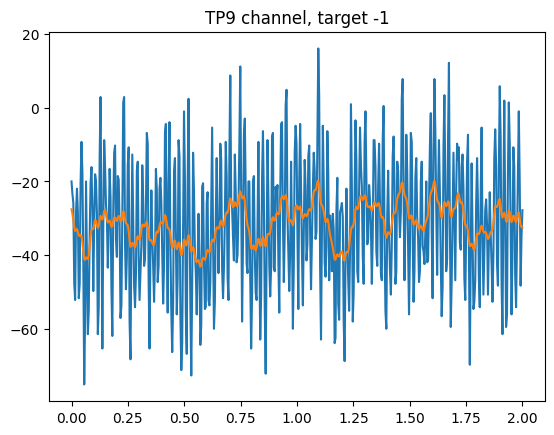

In [ ]:
# Data smoothing to remove noise using TMA filter

# Generated by ChatGPT
def tma_filter(eeg_data, window_size):
    """
    Applies a triangular moving average filter to the EEG data.

    Parameters:
    - eeg_data: np.array, shape (n_channels, n_samples)
      The EEG data to be filtered. Each row corresponds to a channel.
    - window_size: int
      The size of the moving window.

    Returns:
    - filtered_eeg_data: np.array, shape (n_channels, n_samples)
      The filtered EEG data.
    """

    def triangular_kernel(window_size):
        # Generate a triangular kernel
        if window_size % 2 == 0:
            window_size += 1 # make sure the window size is odd
        middle = window_size // 2
        first_half = np.arange(1, middle+2)
        second_half = first_half[:-1][::-1]
        kernel = np.concatenate((first_half, second_half))
        kernel = kernel / kernel.sum()

        return kernel

    kernel = triangular_kernel(window_size)
    smoothed_eeg_data = []

    # Apply filter to each channel
    for i in range(eeg_data.shape[0]):
        mode = 'valid'
        smoothed_channel = np.convolve(eeg_data[i, :], kernel, mode=mode)

        # If mode = 'valid' apply mean padding to front and back of smoothed data
        # if(mode=='valid'):
        #   pad_size = int(eeg_data.shape[1] - smoothed_channel.shape[0])
        #   if (pad_size % 2 == 0):
        #       padding = np.full(int(pad_size / 2), np.average(smoothed_channel))
        #       smoothed_channel = np.append(padding, smoothed_channel) # append to front
        #       smoothed_channel = np.append(smoothed_channel, padding) # append to back

        smoothed_eeg_data.append(smoothed_channel)

    smoothed_eeg_data = np.array(smoothed_eeg_data)


    return smoothed_eeg_data

# smoothed_data = np.zeros_like(data)
# for i in range(data.shape[0]):
#     smoothed_eeg_data = tma_filter(data[i, :], window_size=15) # adjust window size as necessary
#     smoothed_data[i, :] = smoothed_eeg_data

def smooth_data(data, window_size):
    smoothed_data = []
    for i in range(data.shape[0]):
        smoothed_eeg_data = tma_filter(data[i, :], window_size) # adjust window size as necessary
        smoothed_data.append(smoothed_eeg_data)

    smoothed_data = np.array(smoothed_data)
    return  smoothed_data

smoothed_data = smooth_data(data, window_size=15)




# smoothed_data = np.array(smoothed_data)

# Plot example signal before and after smoothing
random.seed()
rand = random.randint(0, data.shape[0])
print("Random data point:", rand)
print("Target is ", target[rand])
raw_sample = data[rand] # all the eeg data from the chosen datapoint
smoothed_sample = smoothed_data[rand]
# time_data = np.linspace(0, 2, desired_samples) # create corresponding time values for each of the eeg signal points, 2 seconds
time_data = np.linspace(0, 2, smoothed_sample.shape[1])

print(raw_sample.shape, smoothed_sample.shape)

cutoff = int((raw_sample.shape[1] - smoothed_sample.shape[1]) / 2)
plt.figure()
plt.title(f'TP9 channel, target {target[rand]}')
plt.plot(time_data, raw_sample[0, cutoff:raw_sample.shape[1]-cutoff], label='raw data')
plt.plot(time_data, smoothed_sample[0], label='smoothed data')

plt.show()


In [ ]:
# # Visualize some digit signals and some blank signals
# random.seed()
# cutoff = int((raw_sample.shape[1] - smoothed_sample.shape[1]) / 2)
# time_data = np.linspace(0, 2, smoothed_sample.shape[1])

# fig, ax = plt.subplots(2)
# fig.suptitle("TP9 channel")

# # Graph some digits
# n_graphs = 0
# while (n_graphs < 2):
#     rand = random.randint(0, data.shape[0])
#     if target[rand] >= 0:
#         raw_sample = data[rand] # all the eeg data from the chosen datapoint
#         smoothed_sample = smoothed_data[rand]
#         ax[n_graphs].plot(time_data, raw_sample[0, cutoff:raw_sample.shape[1]-cutoff], label='raw data')
#         ax[n_graphs].plot(time_data, smoothed_sample[0], label='smoothed data')
#         ax[n_graphs].set_title(f'target {target[rand]}')

#         n_graphs += 1

# plt.show()


In [ ]:
print(smoothed_data[rand])
data = smoothed_data
print(data.shape)

[[ -26.80206315  -27.60314955  -28.77044688 ...  -26.90887437
   -26.69525131  -26.8859862 ]
 [-127.81524569  -97.29766823  -91.82739281 ... -103.46221609
  -141.27349547 -150.29906938]
 [   0.57983356    9.19342014    5.86700422 ...  -12.94708244
   -27.51922597  -27.70233153]
 [ -28.93829337  -29.06036366  -29.80041488 ...  -34.70611583
   -34.91210948  -34.79003912]]
(36000, 4, 498)


In [ ]:
# # Apply min-max scaling to the data EEG sequence
# # Using scikit-learn minmaxscaler but not sure if this is the same transform as the paper used... if stuff doesn't work come back here and do this manually

# data = np.reshape(data, (data.shape[0], -1))
# scaler = MinMaxScaler(feature_range=(0, 1))
# data = scaler.fit_transform(data)
# print(data[0])

# # Reshape back to cnn format
# data = np.reshape(data, (data.shape[0], n_channels, -1))
# print(data.shape)

In [ ]:
# Downsample the data to 40 time steps
# Don't know if this paper used Fourier method or polyphase filtering or what
# Try Fourier first and see what happens

def down_sample(data, n_timesteps):
    #print(data.shape)
    downsampled_data = np.zeros((data.shape[0], n_channels, n_timesteps))
    for i in range(data.shape[0]):
        for j in range(n_channels):
            downsampled_data[i, j] = scipy.signal.resample(data[i, j], n_timesteps)


    #print(downsampled_data.shape)
    return downsampled_data


n_timesteps2=40
downsampled_data = down_sample(data, n_timesteps2)
data = downsampled_data
print(data.shape)


(36000, 4, 40)


## Prepare for input into CNN

In [ ]:
def prepare_binary(data):
    samples=data.shape[2]
    # Apply min-max scaling to the data EEG sequence
    # Using scikit-learn minmaxscaler but not sure if this is the same transform as the paper used... if stuff doesn't work come back here and do this manually

    data = np.reshape(data, (data.shape[0], -1))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data)

    # Reshape back to cnn format
    data = np.reshape(data, (data.shape[0], data.shape[1], -1))

    target_binary = np.zeros_like(target)
    for i in range(target_binary.shape[0]):
        if target[i] == -1:
            target_binary[i] = -1
        else:
            target_binary[i] = 0


    N_CLASSES = 2 # blank/digit classification
    INPUT_SHAPE = (n_channels, samples, 1) # 1 color channel
    BATCH_SIZE = 32

    # Split into train and test set and relabel as X and y
    X_train, X_test, y_train, y_test = train_test_split(data, target_binary, test_size=0.2, random_state=62, shuffle=True)

    # One hot encoding
    y_train = to_categorical(y_train, N_CLASSES)
    y_test = to_categorical(y_test, N_CLASSES)

    # Split train into train and validation set
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=85, shuffle=True)
    X_train = np.reshape(X_train, (X_train.shape[0], n_channels, samples, 1))
    X_val = np.reshape(X_val, (X_val.shape[0], n_channels, samples, 1))


    return X_train, X_val, y_train, y_val


In [ ]:


# Apply min-max scaling to the data EEG sequence
# Using scikit-learn minmaxscaler but not sure if this is the same transform as the paper used... if stuff doesn't work come back here and do this manually

data = np.reshape(data, (data.shape[0], -1))
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data)
print(data[0])

# Reshape back to cnn format
data = np.reshape(data, (data.shape[0], data.shape[1], -1))
print(data.shape)
# Changing problem to blank vs digit problem (use this cell and next one instead of the 2 after if you want to do this)

# Inspect values and counts of target
target_values, target_counts = np.unique(target, return_counts=True)
#print("Values:", target_values)
#print("Counts:", target_counts)

# Iterate through target, creating a new target array that's 1 if it's a 0-9 (digit) and -1 if it's -1 (blank)
target_binary = np.zeros_like(target)
for i in range(target_binary.shape[0]):
    if target[i] == -1:
        target_binary[i] = -1
    else:
        target_binary[i] = 0

# Inspect values and counts of target binary array
target_bin_values, target_bin_counts = np.unique(target_binary, return_counts=True)
print("Values:", target_bin_values)
print("Counts:", target_bin_counts)

# Now keep only the first 11103 digit values

# Split both the data and the binary target into those containing digits and those containing -1 blanks

data_digit = data[target_binary >= 0]
data_blank = data[target_binary == -1]
target_digit = target_binary[target_binary >= 0]
target_blank = target_binary[target_binary == -1]

# Add first 11103 of the digits back into the main set
data_binary = np.concatenate((data_blank, data_digit[:18000]), 0) # join these 2 arrays along the 1st (0) axis
target_binary = np.concatenate((target_blank, target_digit[:18000]), 0)

# Inspect values and counts again
target_bin_values, target_bin_counts = np.unique(target_binary, return_counts=True)
print("Values:", target_bin_values)
print("Counts:", target_bin_counts)


N_CLASSES = 2 # blank/digit classification
INPUT_SHAPE = (n_channels, n_timesteps2, 1) # 1 color channel
print(INPUT_SHAPE)
BATCH_SIZE = 32

# Split into train and test set and relabel as X and y
X_train, X_test, y_train, y_test = train_test_split(data_binary, target_binary, test_size=0.2, random_state=62, shuffle=True)

# Inspect values and counts of y_train
y_train_values, y_train_counts = np.unique(y_train, return_counts=True)
print("Values:", y_train_values)
print("Counts:", y_train_counts)
#print(y_train.shape)

# One hot encoding
y_train = to_categorical(y_train, N_CLASSES)
y_test = to_categorical(y_test, N_CLASSES)
print(y_train[:10])

# Split train into train and validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=85, shuffle=True)

X_train = np.reshape(X_train, (X_train.shape[0], n_channels, n_timesteps2, 1))
X_val = np.reshape(X_val, (X_val.shape[0], n_channels, n_timesteps2, 1))
print(X_train.shape)
print(X_val.shape)


[0.48073587 0.4429375  0.46045907 0.43564441 0.51195839 0.42553159
 0.46948791 0.49506236 0.56526218 0.54327896 0.52522929 0.51894015
 0.60622463 0.55635869 0.47230582 0.5047457  0.39860029 0.5917823
 0.4686476  0.47802661 0.41117725 0.54847392 0.52693746 0.52962177
 0.57979314 0.61559043 0.49426586 0.50509236 0.49888602 0.5113776
 0.59124982 0.45073704 0.52555837 0.45121523 0.49642437 0.52960685
 0.43331587 0.51427506 0.70801388 0.55995085 0.29850496 0.30605773
 0.35678934 0.33528971 0.36104366 0.34356462 0.33594814 0.38447886
 0.35124161 0.36373191 0.39063265 0.37424878 0.34803008 0.37069959
 0.34113443 0.35812309 0.37877505 0.33069166 0.38765678 0.3413471
 0.34773058 0.36725177 0.38487198 0.35512709 0.38316863 0.30089147
 0.36764667 0.36340695 0.35888028 0.30434116 0.33187104 0.3249843
 0.33130153 0.33816714 0.35446477 0.2536122  0.33072629 0.32251714
 0.28902509 0.2878681  0.29904431 0.35728062 0.36082034 0.28519545
 0.30635233 0.29829349 0.33750288 0.3783165  0.34312261 0.32850365

In [ ]:
# Adjusting number of blank values
'''
# Inspect values and counts of target
target_values, target_counts = np.unique(target, return_counts=True)
print("Values:", target_values)
print("Counts:", target_counts)

# Split both the data and the target into those containing 0-9 targets and those containing -1 targets
data_digit = data[target >= 0]
data_blank = data[target == -1]
target_digit = target[target >= 0]
target_blank = target[target == -1]

# # Add first 3000 of the blanks back into the main set
# data = np.concatenate((data_digit, data_blank[:3000]), 0) # join these 2 arrays along the 1st (0) axis
# target = np.concatenate((target_digit, target_blank[:3000]), 0)

# Remove the blanks
data = data_digit
target = target_digit

# Now inspect the values and counts again
print("\nAdjusted number of blanks")
target_values, target_counts = np.unique(target, return_counts=True)
print("Values:", target_values)
print("Counts:", target_counts)

print("Data shape: ", data.shape)
'''

'\n# Inspect values and counts of target\ntarget_values, target_counts = np.unique(target, return_counts=True)\nprint("Values:", target_values)\nprint("Counts:", target_counts)\n\n# Split both the data and the target into those containing 0-9 targets and those containing -1 targets\ndata_digit = data[target >= 0]\ndata_blank = data[target == -1]\ntarget_digit = target[target >= 0]\ntarget_blank = target[target == -1]\n\n# # Add first 3000 of the blanks back into the main set\n# data = np.concatenate((data_digit, data_blank[:3000]), 0) # join these 2 arrays along the 1st (0) axis\n# target = np.concatenate((target_digit, target_blank[:3000]), 0)\n\n# Remove the blanks\ndata = data_digit\ntarget = target_digit\n\n# Now inspect the values and counts again\nprint("\nAdjusted number of blanks")\ntarget_values, target_counts = np.unique(target, return_counts=True)\nprint("Values:", target_values)\nprint("Counts:", target_counts)\n\nprint("Data shape: ", data.shape)\n'

In [ ]:
'''
N_CLASSES = 10 # change this depending on whether you removed the -1 targets (blank, non-digit events) or not
INPUT_SHAPE = (n_channels, n_timesteps, 1) # 1 color channel
BATCH_SIZE = 32

# Split into train and test set and relabel as X and y
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=62, shuffle=True)

# One hot encoding
y_train = to_categorical(y_train, N_CLASSES)
y_test = to_categorical(y_test, N_CLASSES)
print(y_train[0])

# Split train into train and validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=85, shuffle=True)


print(X_train.shape)
print(X_val.shape)
'''

'\nN_CLASSES = 10 # change this depending on whether you removed the -1 targets (blank, non-digit events) or not\nINPUT_SHAPE = (n_channels, n_timesteps, 1) # 1 color channel\nBATCH_SIZE = 32\n\n# Split into train and test set and relabel as X and y\nX_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=62, shuffle=True)\n\n# One hot encoding\ny_train = to_categorical(y_train, N_CLASSES)\ny_test = to_categorical(y_test, N_CLASSES)\nprint(y_train[0])\n\n# Split train into train and validation set\nX_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=85, shuffle=True)\n\nprint(X_train.shape)\nprint(X_val.shape)\n'

## Build and train CNN

In [ ]:
print(INPUT_SHAPE)
print(())

(4, 40, 1)
()


In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
# Build the model from the paper [12]


model = Sequential()
model.add(Input(shape=INPUT_SHAPE))
model.add(Conv2D(filters=16, kernel_size=(1, 5), activation='relu'))
BatchNormalization()
model.add(Conv2D(filters=32, kernel_size=(1, 5), activation='relu'))
BatchNormalization()
model.add(Conv2D(filters=64, kernel_size=(1, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(1, 2))
BatchNormalization()
model.add(Flatten())
#model.add(Dense(1024, activation='relu'))
#model.add(Dense(1024, activation='relu'))
#BatchNormalization()
#model.add(Dense(80, activation='relu'))
model.add(Dense(80, activation='relu'))
#model.add(Dense(32, activation='relu'))
model.add(Dense(N_CLASSES, activation='softmax'))

learning_rate=0.00005
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_42 (Conv2D)          (None, 4, 36, 16)         96        
                                                                 
 conv2d_43 (Conv2D)          (None, 4, 32, 32)         2592      
                                                                 
 conv2d_44 (Conv2D)          (None, 4, 28, 64)         10304     
                                                                 
 flatten_14 (Flatten)        (None, 7168)              0         
                                                                 
 dense_40 (Dense)            (None, 80)                573520    
                                                                 
 dense_41 (Dense)            (None, 2)                 162       
                                                                 
Total params: 586674 (2.24 MB)
Trainable params: 5866

In [ ]:
hist = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=100, validation_data=(X_val, y_val))

Epoch 1/100
720/720 [==============================] - 4s 4ms/step - loss: 0.6939 - accuracy: 0.4957 - val_loss: 0.6935 - val_accuracy: 0.4925
Epoch 2/100
720/720 [==============================] - 3s 4ms/step - loss: 0.6933 - accuracy: 0.5002 - val_loss: 0.6933 - val_accuracy: 0.4924
Epoch 3/100
720/720 [==============================] - 3s 4ms/step - loss: 0.6932 - accuracy: 0.5024 - val_loss: 0.6932 - val_accuracy: 0.4977
Epoch 4/100
720/720 [==============================] - 3s 4ms/step - loss: 0.6932 - accuracy: 0.5031 - val_loss: 0.6933 - val_accuracy: 0.4965
Epoch 5/100
720/720 [==============================] - 3s 4ms/step - loss: 0.6931 - accuracy: 0.5046 - val_loss: 0.6932 - val_accuracy: 0.5231
Epoch 6/100
720/720 [==============================] - 3s 4ms/step - loss: 0.6929 - accuracy: 0.5072 - val_loss: 0.6933 - val_accuracy: 0.5080
Epoch 7/100
720/720 [==============================] - 3s 4ms/step - loss: 0.6928 - accuracy: 0.5103 - val_loss: 0.6935 - val_accuracy: 0.4894

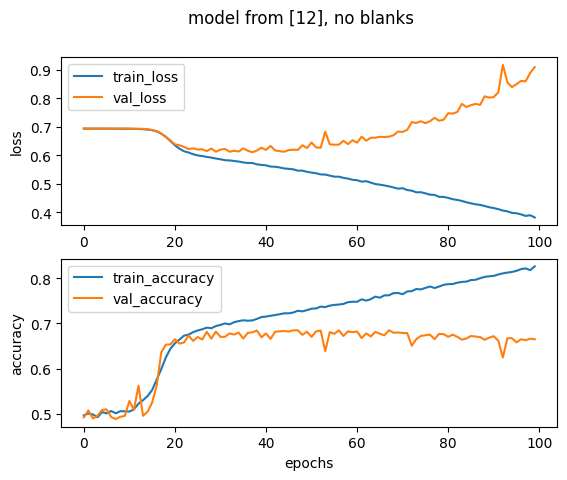

In [ ]:
'''
file_save_path = "train_result/cnn/Muse2/"

if not os.path.exists(file_save_path):
    os.mkdir(file_save_path)
'''
# Plot the training history
fig, ax = plt.subplots(2)
fig.suptitle("model from [12], no blanks")
ax[0].set(ylabel='loss')
ax[1].set(xlabel='epochs', ylabel='accuracy')

ax[0].plot(hist.history['loss'], label='train_loss')
ax[0].plot(hist.history['val_loss'], label='val_loss')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], label='train_accuracy')
ax[1].plot(hist.history['val_accuracy'], label='val_accuracy')
ax[1].legend()

#plt.savefig(file_save_path+"[12]_no_blanks")

plt.show()

# Hyper Parameter Search


In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.0/233.0 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 8.3 MB/s eta 0:00:00


In [ ]:
import optuna
from tensorflow.keras.optimizers import Adam

# Search for the best parameters in preprocessing


In [ ]:
def objective(trial):
    '''
    kernel_size_options = {
    0: (1, 2),
    1: (1, 4),
    2: (1, 6),
    3: (1, 8),
    4: (1, 10),}
    print(kernel_size_options.keys())
    '''
    N_CLASSES=2
    window_size = trial.suggest_int('window_size', 5, 50, step=5)
    n_timesteps = trial.suggest_int('n_timesteps', 30, 100, step=10)
    #kernel_size = trial.suggest_categorical('kernel_size',list(kernel_size_options.items()))
    kernel_size = trial.suggest_categorical('kernel_size', [(1, 4), (1, 6), (1, 8), (1, 10)])

    smoothed_data = smooth_data(initial_data, window_size)
    downsampled_data = down_sample(smoothed_data, n_timesteps)
    X_train, X_val, y_train, y_val = prepare_binary(downsampled_data)
    #print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

    INPUT_SHAPE = (n_channels, n_timesteps, 1)
    #print(INPUT_SHAPE)

    model = Sequential()
    model.add(Input(shape=INPUT_SHAPE))
    model.add(Conv2D(filters=16, kernel_size=kernel_size, activation='relu'))
    BatchNormalization()
    model.add(Conv2D(filters=32, kernel_size=kernel_size, activation='relu'))
    BatchNormalization()
    model.add(Conv2D(filters=64, kernel_size=kernel_size, activation='relu'))
    BatchNormalization()
    model.add(Flatten())
    model.add(Dense(80, activation='relu'))
    model.add(Dense(N_CLASSES, activation='softmax'))

    learning_rate=0.00005
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=50, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), verbose=0)

    # Get validation accuracy
    val_accuracy = np.max(history.history['val_accuracy'])

    return val_accuracy

# Create study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

# Get the best hyperparameters
best_hyperparams = study.best_params
print(best_hyperparams)

[I 2024-07-29 20:31:48,405] A new study created in memory with name: no-name-f63f0fde-0595-4dd2-8264-9b491b0a6122
/usr/local/lib/python3.10/dist-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 4) which is of type tuple.
  warnings.warn(message)
/usr/local/lib/python3.10/dist-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 6) which is of type tuple.
  warnings.warn(message)
/usr/local/lib/python3.10/dist-packages/optuna/distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 8) which is of type tuple.
  warnings.warn(message)
/usr/local/lib/python3.10/dist-packages/optuna/distributions.py:524: UserWarning: Choices f

{'window_size': 10, 'n_timesteps': 90, 'kernel_size': (1, 10)}


In [ ]:
optuna.visualization.plot_slice(study)

In [ ]:
optuna.visualization.plot_optimization_history(study)

In [ ]:

study_df = study.trials_dataframe()
study_df.to_csv('/content/drive/My Drive/ML project/optuna_study_preprocessing.csv')


In [ ]:
print(type(study))

<class 'optuna.study.study.Study'>


In [ ]:
from optuna.visualization import plot_optimization_history, plot_param_importances
from optuna.visualization import plot_parallel_coordinate, plot_contour, plot_slice, plot_edf
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

opt_history = plot_optimization_history(study)
opt_history.write_html('/content/drive/My Drive/ML project/optuna_plots_study_prepro/optuna_optimization_history.html'))

param_importances = plot_param_importances(study)
param_importances.write_html('/content/drive/My Drive/ML project/optuna_plots_study_prepro/optuna_param_importances.html'))

parallel_coord = plot_parallel_coordinate(study)
parallel_coord.write_html('/content/drive/My Drive/ML project/optuna_plots_study_prepro/optuna_parallel_coordinate.html'))

contour_plot = plot_contour(study)
contour_plot.write_html('/content/drive/My Drive/ML project/optuna_plots_study_prepro/optuna_contour_plot.html'))

slice_plot = plot_slice(study)
slice_plot.write_html('/content/drive/My Drive/ML project/optuna_plots_study_prepro/optuna_slice_plot.html'))

edf_plot = plot_edf(study)
edf_plot.write_html('/content/drive/My Drive/ML project/optuna_plots_study_prepro/optuna_edf_plot.html'))

rank_plot = plot_rank(study)
rank_plot.write_html('/content/drive/My Drive/ML project/optuna_plots_study_prepro/optuna_rank_plot.html'))

# Search for Hyperparameters in the CNN

In [ ]:
N_CLASSES=2
window_size = 10
n_timesteps = 90
smoothed_data = smooth_data(initial_data, window_size)
downsampled_data = down_sample(smoothed_data, n_timesteps)
X_train, X_val, y_train, y_val = prepare_binary(downsampled_data)
#print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

INPUT_SHAPE = (n_channels, n_timesteps, 1)

In [ ]:
def create_model(trial):
    # Define hyperparameters

    num_dense_layers = trial.suggest_int('num_dense_layers', 1, 3)
    num_conv_layers = trial.suggest_int('num_conv_layers', 2, 4)
    dense_units1 = trial.suggest_int('dense_units1', 64, 256, step=32)
    dense_units2 = trial.suggest_int('dense_units2', 64, 196, step=32)
    dense_units3 = trial.suggest_int('dense_units3', 64, 196, step=32)

    kernel_size2 = trial.suggest_categorical('kernel_size2', [(1, 8), (1, 10)])
    kernel_size3 = trial.suggest_categorical('kernel_size3', [(1, 4), (1, 6), (1, 8), (1, 10)])
    kernel_size4 = trial.suggest_categorical('kernel_size4', [(1, 4), (1, 6), (1, 8), (1, 10)])

    num_filters1 = trial.suggest_int('num_filters1', 16, 32, step=16)
    num_filters2 = trial.suggest_int('num_filters2', 16, 32, step=16)
    num_filters3 = trial.suggest_int('num_filters3', 32, 64, step=16)
    num_filters4 = trial.suggest_int('num_filters3', 64, 128, step=32)



    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5, step=0.1)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh', 'elu', 'selu'])
    #learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    learning_rate = 0.0005

    # Create model
    model = Sequential()
    model.add(Input(shape=INPUT_SHAPE))
    model.add(Conv2D(filters=num_filters1, kernel_size=(1, 10), activation='relu'))
    BatchNormalization()
    model.add(Conv2D(filters=num_filters2, kernel_size=kernel_size2, activation='relu'))
    BatchNormalization()

    if num_conv_layers == 3:
        model.add(Conv2D(filters=num_filters3, kernel_size=kernel_size3, activation='relu'))
        BatchNormalization()
    elif num_conv_layers == 4:
        model.add(Conv2D(filters=num_filters3, kernel_size=kernel_size3, activation='relu'))
        BatchNormalization()
        model.add(Conv2D(filters=num_filters4, kernel_size=kernel_size4, activation='relu'))
        BatchNormalization()

    model.add(Flatten())

    model.add(Dense(dense_units1, activation=activation))
    model.add(Dropout(rate=dropout_rate))

    if num_dense_layers == 2:
        model.add(Dense(dense_units2, activation=activation))
        model.add(Dropout(dropout_rate))
    if num_dense_layers == 3:
        model.add(Dense(dense_units2, activation=activation))
        model.add(Dropout(dropout_rate))
        model.add(Dense(dense_units3, activation=activation))
        model.add(Dropout(dropout_rate))

    model.add(Dense(N_CLASSES, activation='softmax'))

    # Compile model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def objective(trial):
    model = create_model(trial)

    # Train the model
    history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=0)

    # Get validation accuracy
    val_accuracy = np.max(history.history['val_accuracy'])

    return val_accuracy

# Create study and optimize
storage_name = "sqlite:///optuna_study2.db"
study2_name = "cnn_study2"
study2 = optuna.create_study(study_name=study2_name, storage=storage_name, direction='maximize', load_if_exists=True)
study2.optimize(objective, n_trials=70)

# Get the best hyperparameters


[I 2024-07-30 04:52:59,326] Using an existing study with name 'cnn_study2' instead of creating a new one.
[I 2024-07-30 04:55:22,056] Trial 1 finished with value: 0.660069465637207 and parameters: {'num_dense_layers': 3, 'num_conv_layers': 3, 'dense_units1': 224, 'dense_units2': 192, 'dense_units3': 96, 'kernel_size2': [1, 8], 'kernel_size3': [1, 4], 'kernel_size4': [1, 10], 'num_filters1': 16, 'num_filters2': 16, 'num_filters3': 64, 'dropout_rate': 0.30000000000000004, 'activation': 'selu'}. Best is trial 1 with value: 0.660069465637207.
[I 2024-07-30 04:57:07,985] Trial 2 finished with value: 0.6329861283302307 and parameters: {'num_dense_layers': 1, 'num_conv_layers': 2, 'dense_units1': 192, 'dense_units2': 128, 'dense_units3': 64, 'kernel_size2': [1, 8], 'kernel_size3': [1, 10], 'kernel_size4': [1, 4], 'num_filters1': 16, 'num_filters2': 32, 'num_filters3': 64, 'dropout_rate': 0.4, 'activation': 'selu'}. Best is trial 1 with value: 0.660069465637207.
[I 2024-07-30 04:59:30,225] Tri

NameError: name 'study' is not defined

In [ ]:
best_hyperparams = study2.best_params
print(best_hyperparams)

In [ ]:
study_df = study.trials_dataframe()
study_df.to_csv('/content/drive/My Drive/ML project/optuna_study_hyperparameters.csv')